In [2]:
import pandas as pd
import numpy as np

In [3]:
# ==========================================
# 0. 读取数据并先看最基础的结构
# ==========================================
taxi = pd.read_parquet("../data/yellow_tripdata_2025-12.parquet")

print("数据形状 (行数, 列数):", taxi.shape)
print("各列数据类型:\n", taxi.dtypes)
print("前 5 行数据预览:\n", taxi.head())


# ==========================================
# 1. dtype: 先确认每一列是不是我们以为的类型
# ==========================================
# Parquet 往往会保留 datetime dtype，但分析前仍建议显式确认
print("转换前各列数据类型:\n", taxi.dtypes)

# 统一确认上车 / 下车时间列，并顺手构造行程时长（分钟）
taxi["tpep_pickup_datetime"] = pd.to_datetime(
    taxi["tpep_pickup_datetime"],
    errors="coerce",
)
taxi["tpep_dropoff_datetime"] = pd.to_datetime(
    taxi["tpep_dropoff_datetime"],
    errors="coerce",
)
taxi = taxi.assign(
    trip_minutes=(
        taxi["tpep_dropoff_datetime"] - taxi["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60
)

print("转换后各列数据类型:\n", taxi.dtypes)


# ==========================================
# 2. 缺失值诊断
# ==========================================
# isna() 会返回同形状的布尔表；sum() 会把 True 当作 1 来累计
missing_summary = pd.DataFrame(
    {
        "missing_count": taxi.isna().sum(),
        "missing_rate": taxi.isna().mean().mul(100),
    }
).sort_values("missing_count", ascending=False)

print("各列缺失值统计:\n", missing_summary)


# ==========================================
# 3. 使用 mask 批量定义“可信数据”规则
# ==========================================
# 新版黄出租车数据可以直接利用完整字段定义业务边界：
# - 车费与总金额应当 > 0
# - 行程距离应当 > 0
# - 下车时间应晚于上车时间
# - 上下车区域 ID 应当为正整数
mask_positive_fare = taxi["fare_amount"] > 0
mask_positive_total = taxi["total_amount"] > 0
mask_positive_distance = taxi["trip_distance"] > 0
mask_valid_duration = taxi["trip_minutes"] > 0
mask_valid_location = (
    (taxi["PULocationID"] > 0)
    & (taxi["DOLocationID"] > 0)
)

mask_valid = (
    mask_positive_fare
    & mask_positive_total
    & mask_positive_distance
    & mask_valid_duration
    & mask_valid_location
)

print("可信数据占比:", mask_valid.mean())


# ==========================================
# 4. loc: 精确抽取异常行进行排查
# ==========================================
bad_rows = taxi.loc[
    ~mask_valid,
    [
        "fare_amount",
        "total_amount",
        "trip_distance",
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "trip_minutes",
        "passenger_count",
        "PULocationID",
        "DOLocationID",
    ],
]

print("异常行前 10 条:\n", bad_rows.head(10))


# ==========================================
# 5. query: 用更接近 SQL 的方式做业务筛选
# ==========================================
clean_taxi = taxi.query(
    "fare_amount > 0 and total_amount > 0 and trip_distance > 0 "
    "and trip_minutes > 0 and PULocationID > 0 and DOLocationID > 0"
).copy()

print("query 筛选后数据形状 (行数, 列数):", clean_taxi.shape)


# ==========================================
# 6. 进一步把异常类型分类，而不是只做二元过滤
# ==========================================
taxi["quality_flag"] = np.select(
    [
        taxi["fare_amount"] <= 0,
        taxi["total_amount"] <= 0,
        taxi["trip_distance"] <= 0,
        taxi["tpep_pickup_datetime"].isna() | taxi["tpep_dropoff_datetime"].isna(),
        taxi["trip_minutes"] <= 0,
        taxi["passenger_count"].isna(),
        taxi["passenger_count"] <= 0,
        (taxi["PULocationID"] <= 0) | (taxi["DOLocationID"] <= 0),
    ],
    [
        "bad_fare",
        "bad_total_amount",
        "bad_trip_distance",
        "bad_datetime",
        "bad_trip_duration",
        "missing_passenger_count",
        "bad_passenger_count",
        "invalid_location_id",
    ],
    default="ok",
)

print("数据质量标记分布:\n", taxi["quality_flag"].value_counts())

数据形状 (行数, 列数): (4305006, 20)
各列数据类型:
 VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object
前 5 行数据预览:
    VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2025-12-01 00:37:08   2025-12-01 00:51:10       

In [4]:
# ==========================================
# Q2. 一天中什么时候最忙？
# API: datetime / groupby / agg
# ==========================================
q2_df = clean_taxi.copy()

# datetime 已在前面转好；这里继续派生出小时字段
q2_df = q2_df.assign(
    pickup_hour=q2_df["tpep_pickup_datetime"].dt.hour,
    pickup_weekday=q2_df["tpep_pickup_datetime"].dt.day_name(),
)

# 按小时统计订单量、平均客单价、总流水
hourly_summary = (
    q2_df
    .groupby("pickup_hour", as_index=False)
    .agg(
        order_count=("total_amount", "size"),
        total_revenue=("total_amount", "sum"),
        avg_total_amount=("total_amount", "mean"),
    )
    .sort_values("order_count", ascending=False)
)

print("按小时订单量/总流水/平均客单价汇总:\n", hourly_summary)

# 如果还想看“工作日不同小时”的热度分布
hour_weekday_summary = (
    q2_df
    .groupby(["pickup_weekday", "pickup_hour"])
    .agg(order_count=("total_amount", "size"))
    .reset_index()
)

print("工作日不同小时的热度分布(前20条):\n", hour_weekday_summary.head(20))

按小时订单量/总流水/平均客单价汇总:
     pickup_hour  order_count  total_revenue  avg_total_amount
18           18       251642     7892051.34         31.362218
15           15       250462     8114502.70         32.398139
17           17       246679     8141923.37         33.006147
21           21       243809     7758771.12         31.823153
20           20       237157     7193859.49         30.333743
19           19       236551     7314219.01         30.920262
16           16       234910     8013309.70         34.112254
14           14       234748     7500699.68         31.952135
22           22       227596     7449052.77         32.729278
13           13       218943     6756853.83         30.861246
12           12       210402     6316880.12         30.022909
11           11       197800     5909325.77         29.875257
23           23       189011     6198690.53         32.795396
10           10       182234     5315164.51         29.166701
9             9       171973     4959246.02      

In [9]:
print(type(hour_weekday_summary))

<class 'pandas.core.frame.DataFrame'>


In [5]:
# ==========================================
# Q3. 什么时间段的流水和单位运营时间收入最高？
# API: 向量化 / assign / groupby / 派生指标 / transform
# ==========================================
q3_df = clean_taxi.copy()

# 这次数据已经同时包含上车 / 下车时间，可以直接构造真实的运营时长指标

q3_df = q3_df.assign(
    pickup_hour=q3_df["tpep_pickup_datetime"].dt.hour,
    revenue_per_minute=q3_df["total_amount"] / q3_df["trip_minutes"],
    fare_per_mile=q3_df["fare_amount"] / q3_df["trip_distance"],
)

# 按小时汇总：总流水、订单量、总运营分钟数、单位运营时间收入
hour_efficiency = (
    q3_df
    .groupby("pickup_hour", as_index=False)
    .agg(
        total_revenue=("total_amount", "sum"),
        order_count=("total_amount", "size"),
        total_trip_minutes=("trip_minutes", "sum"),
        avg_trip_distance=("trip_distance", "mean"),
        avg_revenue_per_minute=("revenue_per_minute", "mean"),
    )
)

# 进一步构造“每单平均流水”和“每分钟流水”两个课堂可解释指标
hour_efficiency = hour_efficiency.assign(
    revenue_per_trip_minute=hour_efficiency["total_revenue"] / hour_efficiency["total_trip_minutes"],
    revenue_per_order=hour_efficiency["total_revenue"] / hour_efficiency["order_count"],
)

print("按小时总流水降序:\n", hour_efficiency.sort_values("total_revenue", ascending=False))
print("按单位运营时间收入降序:\n", hour_efficiency.sort_values("revenue_per_trip_minute", ascending=False))

# transform: 把“组内平均每分钟收入”贴回每一行，用来衡量某单是否高于所在小时平均水平
q3_df["hour_avg_revenue_per_minute"] = q3_df.groupby("pickup_hour")["revenue_per_minute"].transform("mean")
q3_df["rpm_vs_hour_avg"] = q3_df["revenue_per_minute"] / q3_df["hour_avg_revenue_per_minute"]

print(
    "每笔订单相对所在小时单位运营时间收入(前10条):\n",
    q3_df.loc[
        :,
        [
            "tpep_pickup_datetime",
            "tpep_dropoff_datetime",
            "pickup_hour",
            "trip_minutes",
            "total_amount",
            "revenue_per_minute",
            "hour_avg_revenue_per_minute",
            "rpm_vs_hour_avg",
        ]
    ].head(10)
)

按小时总流水降序:
     pickup_hour  total_revenue  order_count  total_trip_minutes  \
17           17     8141923.37       246679        5.350412e+06   
15           15     8114502.70       250462        5.693513e+06   
16           16     8013309.70       234910        5.451584e+06   
18           18     7892051.34       251642        4.846900e+06   
21           21     7758771.12       243809        4.133282e+06   
14           14     7500699.68       234748        5.197500e+06   
22           22     7449052.77       227596        3.874290e+06   
19           19     7314219.01       236551        4.300315e+06   
20           20     7193859.49       237157        4.156325e+06   
13           13     6756853.83       218943        4.545472e+06   
12           12     6316880.12       210402        4.234089e+06   
23           23     6198690.53       189011        3.157433e+06   
11           11     5909325.77       197800        3.954065e+06   
10           10     5315164.51       182234        

In [12]:
q4_df = clean_taxi.copy()

# 统计最热门上车区域 / 下车区域
pickup_hotspots = (
    q4_df["PULocationID"]
    .value_counts()
    .rename_axis("LocationID")
    .reset_index(name="pickup_count")
)

dropoff_hotspots = (
    q4_df["DOLocationID"]
    .value_counts()
    .rename_axis("LocationID")
    .reset_index(name="dropoff_count")
)

print("最热门上车区域(前10):\n", pickup_hotspots.head(10))
print("最热门下车区域(前10):\n", dropoff_hotspots.head(10))

# 读取官方 taxi zone lookup 维表，补充 Borough / Zone / service_zone 等真实区域信息
location_dim = pd.read_csv("../data/taxi_zone_lookup.csv")

location_popularity = (
    pickup_hotspots
    .merge(
        dropoff_hotspots,
        on="LocationID",
        how="outer",
        validate="one_to_one",
    )
    .fillna({"pickup_count": 0, "dropoff_count": 0})
    .astype({"pickup_count": "int64", "dropoff_count": "int64"})
    .assign(total_count=lambda x: x["pickup_count"] + x["dropoff_count"])
    .merge(
        location_dim,
        on="LocationID",
        how="left",
        validate="many_to_one",
    )
    .sort_values("total_count", ascending=False)
)

print("上下车区域综合热度(前20):\n", location_popularity.head(20))

最热门上车区域(前10):
    LocationID  pickup_count
0         237        185979
1         236        167408
2         161        154024
3         132        152198
4         186        128412
5         142        126722
6         162        124779
7         230        115023
8         239        107220
9         138        106518
最热门下车区域(前10):
    LocationID  dropoff_count
0         236         167308
1         237         166587
2         161         139498
3         230         110510
4         162         109607
5         170         108753
6         142         105922
7         239         104531
8          68         101831
9         141          99341
上下车区域综合热度(前20):
      LocationID  pickup_count  dropoff_count  total_count    Borough  \
232         237        185979         166587       352566  Manhattan   
231         236        167408         167308       334716  Manhattan   
157         161        154024         139498       293522  Manhattan   
158         162        124779         

In [15]:
# ==========================================
# Q5. 哪些订单和时间窗口可能异常？
# API: where / select / quantile / transform / resample / rolling
# ==========================================
q5_df = (
    clean_taxi
    .copy()
    .assign(revenue_per_minute=lambda x: x["total_amount"] / x["trip_minutes"])
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["revenue_per_minute"])
    .sort_values("tpep_pickup_datetime")
)

# 以时间列为索引，后续 resample / rolling 更自然
q5_df = q5_df.set_index("tpep_pickup_datetime")


# ==========================================
# 1. 先做单笔订单层面的分位数异常判断
# ==========================================
rpm_q01 = q5_df["revenue_per_minute"].quantile(0.01)
rpm_q99 = q5_df["revenue_per_minute"].quantile(0.99)

q5_df["rpm_outlier_flag"] = np.select(
    [
        q5_df["revenue_per_minute"] < rpm_q01,
        q5_df["revenue_per_minute"] > rpm_q99,
    ],
    ["too_low", "too_high"],
    default="normal",
)

print("单位运营时间收入异常标记分布:\n", q5_df["rpm_outlier_flag"].value_counts())


# ==========================================
# 2. transform: 看每笔订单是否明显偏离“所在小时”的正常水平
# ==========================================
hour_key = q5_df.index.floor("1h")

q5_df["hourly_median_rpm"] = q5_df.groupby(hour_key)["revenue_per_minute"].transform("median")
q5_df["hourly_p95_rpm"] = q5_df.groupby(hour_key)["revenue_per_minute"].transform(
    lambda s: s.quantile(0.95)
)

q5_df["rpm_vs_hourly_median"] = q5_df["revenue_per_minute"] / q5_df["hourly_median_rpm"]
q5_df["within_hour_flag"] = np.where(
    q5_df["revenue_per_minute"] > q5_df["hourly_p95_rpm"],
    "above_hour_p95",
    "normal",
)


# ==========================================
# 3. where: 只保留异常值，其余置空，方便快速抽查
# ==========================================
q5_df["abnormal_rpm_only"] = q5_df["revenue_per_minute"].where(
    q5_df["within_hour_flag"] == "above_hour_p95"
)

print(
    "超过所在小时 p95 的订单(前10条):\n",
    q5_df.loc[
        q5_df["within_hour_flag"] == "above_hour_p95",
        [
            "trip_minutes",
            "total_amount",
            "revenue_per_minute",
            "hourly_median_rpm",
            "hourly_p95_rpm",
            "abnormal_rpm_only",
        ],
    ].head(10)
)


# ==========================================
# 4. resample: 看时间窗口层面的订单量和流水异常
# ==========================================
window_summary = (
    q5_df
    .resample("1h")
    .agg(
        order_count=("total_amount", "size"),
        total_revenue=("total_amount", "sum"),
        avg_revenue_per_minute=("revenue_per_minute", "mean"),
    )
)

window_summary["revenue_ma_24h"] = window_summary["total_revenue"].rolling(24, min_periods=1).mean()
window_summary["orders_ma_24h"] = window_summary["order_count"].rolling(24, min_periods=1).mean()

window_summary["revenue_spike_ratio"] = (
    window_summary["total_revenue"] / window_summary["revenue_ma_24h"]
)

window_summary["order_spike_ratio"] = (
    window_summary["order_count"] / window_summary["orders_ma_24h"]
)

print("流水突增比最高的时间窗口(前10):\n", window_summary.sort_values("revenue_spike_ratio", ascending=False).head(10))


# ==========================================
# 5. rolling: 基于滑动窗口构造动态阈值
# ==========================================
window_summary["rolling_revenue_mean_6h"] = (
    window_summary["total_revenue"].rolling(6, min_periods=3).mean()
)
window_summary["rolling_revenue_std_6h"] = (
    window_summary["total_revenue"].rolling(6, min_periods=3).std()
)

window_summary["revenue_upper_bound"] = (
    window_summary["rolling_revenue_mean_6h"]
    + 3 * window_summary["rolling_revenue_std_6h"]
)

window_summary["window_flag"] = np.where(
    window_summary["total_revenue"] > window_summary["revenue_upper_bound"],
    "possible_spike",
    "normal",
)

print("疑似流水突增窗口(前20):\n", window_summary[window_summary["window_flag"] == "possible_spike"].head(20))

单位运营时间收入异常标记分布:
 rpm_outlier_flag
normal      3968716
too_low       40498
too_high      40497
Name: count, dtype: int64
超过所在小时 p95 的订单(前10条):
                       trip_minutes  total_amount  revenue_per_minute  \
tpep_pickup_datetime                                                   
2025-11-30 21:29:10       8.283333         16.02            1.934004   
2025-11-30 23:57:39      26.500000         98.25            3.707547   
2025-12-01 00:00:13      14.433333         62.09            4.301848   
2025-12-01 00:01:16       2.633333         29.76           11.301266   
2025-12-01 00:01:21      10.983333         96.24            8.762367   
2025-12-01 00:01:30      14.083333         60.96            4.328521   
2025-12-01 00:01:59      13.900000         60.12            4.325180   
2025-12-01 00:02:04       1.200000         12.18           10.150000   
2025-12-01 00:02:07       3.683333         17.22            4.675113   
2025-12-01 00:02:18      21.483333        101.94            4.745

In [24]:
print(window_summary)

                      order_count  total_revenue  avg_revenue_per_minute  \
tpep_pickup_datetime                                                       
2025-11-30 20:00:00             1          14.05                1.584586   
2025-11-30 21:00:00             2          33.47                1.755406   
2025-11-30 22:00:00             0           0.00                     NaN   
2025-11-30 23:00:00             6         302.13                2.601488   
2025-12-01 00:00:00          2110       83579.24                3.718044   
...                           ...            ...                     ...   
2025-12-31 19:00:00          6618      201238.03                2.517743   
2025-12-31 20:00:00          7743      238727.70                2.556390   
2025-12-31 21:00:00          7578      228883.33                2.307101   
2025-12-31 22:00:00          6860      205659.70                2.352915   
2025-12-31 23:00:00          5274      158682.37                3.182813   

           

In [17]:
print(rpm_q01)

0.6212385570623187


In [19]:
print(q5_df["abnormal_rpm_only"])

tpep_pickup_datetime
2025-11-30 20:48:56         NaN
2025-11-30 21:29:10    1.934004
2025-11-30 21:49:06         NaN
2025-11-30 23:53:25         NaN
2025-11-30 23:56:40         NaN
                         ...   
2025-12-31 23:59:45         NaN
2025-12-31 23:59:49         NaN
2025-12-31 23:59:51         NaN
2025-12-31 23:59:54         NaN
2025-12-31 23:59:57         NaN
Name: abnormal_rpm_only, Length: 4049711, dtype: float64


In [34]:
from pathlib import Path
import gc
import math
import os
import platform
import sys
import time
import timeit
from pathlib import Path
from urllib.request import urlretrieve
def benchmark(
    cases: dict[str, callable],
    *,
    repeat: int = 5,
    number: int = 1,
    warmup: int = 1,
) -> pd.DataFrame:
    """
    对多个无参 callable 做简单 benchmark. 

    注意：
    - 这不是严格的微架构性能实验工具；
    - 用于课堂比较“数量级”和相对趋势；
    - 正式性能报告应该固定 CPU、电源策略、数据、线程数和环境. 
    """
    records = []

    for name, func in cases.items():
        for _ in range(warmup):
            func()

        gc.collect()

        times = np.asarray(
            timeit.repeat(
                stmt=func,
                repeat=repeat,
                number=number,
            ),
            dtype=np.float64,
        ) / number

        records.append(
            {
                "name": name,
                "median_ms": np.median(times) * 1000,
                "min_ms": times.min() * 1000,
                "max_ms": times.max() * 1000,
            }
        )

    return (
        pd.DataFrame(records)
        .sort_values("median_ms")
        .reset_index(drop=True)
    )


def plot_benchmark(result: pd.DataFrame, title: str) -> None:
    ordered = result.sort_values("median_ms", ascending=True)

    plt.figure(figsize=(9, 4.5))
    plt.barh(ordered["name"], ordered["median_ms"])
    plt.xlabel("Median time (ms)")
    plt.ylabel("")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def dataframe_memory_mb(df: pd.DataFrame) -> float:
    return df.memory_usage(index=True, deep=True).sum() / 1024**2


def file_size_mb(path: Path) -> float:
    return path.stat().st_size / 1024**2

In [41]:
TAXI_PARQUET_PATH = "../data/yellow_tripdata_2025-12.parquet"
BENCH_ROWS = 2000000

与 python_loop 的结果一致性:
apply     : True
vectorized: True
numba     : True
原始基准数据内存占用 (MB): 160.33050537109375
优化后基准数据内存占用 (MB): 103.8504409790039
性能对比结果:
            name     median_ms        min_ms        max_ms
0         numba     28.397125     28.188584     28.926417
1    vectorized    264.825291    259.346750    270.557750
2   python_loop   2970.241250   2946.994917   2973.578833
3  pandas_apply  64648.364750  64353.074208  66951.015625


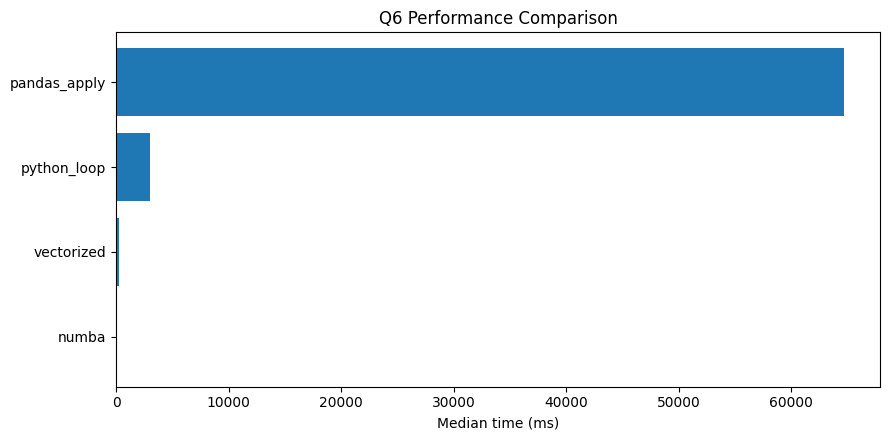

In [42]:
# ==========================================
# Q6. 为什么同一个分析可以相差一个数量级甚至更多？
# API: Python loop / apply / NumPy / Numba / dtype / Parquet
# ==========================================
bench_cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount",
]

# 只取一批样本做 benchmark，并且只读取这次实验真正需要的列。
# 这样可以把 I/O 和内存占用控制在课堂可接受范围内。
bench_df = next(
    pq.ParquetFile(TAXI_PARQUET_PATH).iter_batches(
        batch_size=BENCH_ROWS,
        columns=bench_cols,
    )
).to_pandas()

# 清洗步骤统一放到 benchmark 外面，确保后面所有方案做的是完全相同的工作。
bench_df = (
    bench_df
    .assign(
        trip_minutes=lambda x: (
            x["tpep_dropoff_datetime"] - x["tpep_pickup_datetime"]
        ).dt.total_seconds() / 60,
        passenger_count_filled=lambda x: x["passenger_count"].fillna(1.0).clip(lower=1),
    )
    .query(
        "trip_minutes > 0 and trip_distance > 0 "
        "and total_amount > 0 and fare_amount > 0"
    )
    .copy()
)


# ==========================================
# 1. Python loop: 基线参考组
# ==========================================
# 这次不只比较一个简单的 revenue_per_minute，而是构造一个更复杂的一维数值核。
# 所有方案都只计算同一个一维 efficiency_score，返回长度与 bench_df 相同的结果。
# 公式里故意加入：
# - 多列参与；
# - 多层 if/else 分支；
# - 5 轮重复更新；
# 这样更能体现 Numba 在复杂数值循环上的优势。
def python_loop_efficiency_score() -> list[float]:
    out = []
    total_amounts = bench_df["total_amount"].to_list()
    trip_minutes = bench_df["trip_minutes"].to_list()
    trip_distance = bench_df["trip_distance"].to_list()
    fare_amounts = bench_df["fare_amount"].to_list()
    tip_amounts = bench_df["tip_amount"].to_list()
    payment_types = bench_df["payment_type"].to_list()
    passenger_counts = bench_df["passenger_count_filled"].to_list()

    for total_amount, minutes, distance, fare, tip, payment_type, passenger_count in zip(
        total_amounts,
        trip_minutes,
        trip_distance,
        fare_amounts,
        tip_amounts,
        payment_types,
        passenger_counts,
    ):
        speed = distance / minutes
        spend_rate = total_amount / minutes
        score = (
            0.20 * speed
            + 0.04 * spend_rate
            + 0.03 * fare
            + 0.02 * passenger_count
            - 0.015 * minutes
        )

        for k in range(5):
            mix = (
                speed * (1.03 + 0.02 * k)
                + spend_rate * (0.70 + 0.03 * k)
                + passenger_count * (0.24 + 0.04 * k)
            )

            if payment_type == 1:
                score += 0.10 * fare + 0.05 * mix + 0.01 * tip
            elif payment_type == 2:
                score += 0.08 * total_amount + 0.04 * mix - 0.12
            else:
                score += 0.06 * fare + 0.05 * mix - 0.02 * payment_type

            if score > 11.0 + 0.9 * k:
                score = score * 0.85 + total_amount * (0.025 + 0.003 * k)
            else:
                score = score * 1.04 - minutes * (0.010 + 0.002 * k)

            if tip > fare * (0.18 + 0.012 * k):
                score += 0.16 * (k + 1)
            else:
                score -= 0.06 * (k + 1)

            if mix > total_amount * (0.30 + 0.015 * k):
                score += 0.020 * mix - 0.010 * passenger_count
            else:
                score = score - 0.015 * mix + 0.008 * speed

        out.append(score)

    return out


# ==========================================
# 2. apply: 看似 DataFrame 风格，很多场景仍然回退到 Python 层
# ==========================================
def pandas_apply_efficiency_score() -> pd.Series:
    def score_row(row: pd.Series) -> float:
        speed = row["trip_distance"] / row["trip_minutes"]
        spend_rate = row["total_amount"] / row["trip_minutes"]
        score = (
            0.20 * speed
            + 0.04 * spend_rate
            + 0.03 * row["fare_amount"]
            + 0.02 * row["passenger_count_filled"]
            - 0.015 * row["trip_minutes"]
        )

        for k in range(5):
            mix = (
                speed * (1.03 + 0.02 * k)
                + spend_rate * (0.70 + 0.03 * k)
                + row["passenger_count_filled"] * (0.24 + 0.04 * k)
            )

            if row["payment_type"] == 1:
                score += 0.10 * row["fare_amount"] + 0.05 * mix + 0.01 * row["tip_amount"]
            elif row["payment_type"] == 2:
                score += 0.08 * row["total_amount"] + 0.04 * mix - 0.12
            else:
                score += 0.06 * row["fare_amount"] + 0.05 * mix - 0.02 * row["payment_type"]

            if score > 11.0 + 0.9 * k:
                score = score * 0.85 + row["total_amount"] * (0.025 + 0.003 * k)
            else:
                score = score * 1.04 - row["trip_minutes"] * (0.010 + 0.002 * k)

            if row["tip_amount"] > row["fare_amount"] * (0.18 + 0.012 * k):
                score += 0.16 * (k + 1)
            else:
                score -= 0.06 * (k + 1)

            if mix > row["total_amount"] * (0.30 + 0.015 * k):
                score += 0.020 * mix - 0.010 * row["passenger_count_filled"]
            else:
                score = score - 0.015 * mix + 0.008 * speed

        return score

    return bench_df.apply(score_row, axis=1)


# ==========================================
# 3. NumPy / Pandas 向量化：课堂中应优先追求的写法
# ==========================================
def vectorized_efficiency_score() -> np.ndarray:
    speed = bench_df["trip_distance"] / bench_df["trip_minutes"]
    spend_rate = bench_df["total_amount"] / bench_df["trip_minutes"]
    fare = bench_df["fare_amount"]
    tip = bench_df["tip_amount"]
    total = bench_df["total_amount"]
    minutes = bench_df["trip_minutes"]
    payment = bench_df["payment_type"]
    passenger = bench_df["passenger_count_filled"]

    score = (
        0.20 * speed
        + 0.04 * spend_rate
        + 0.03 * fare
        + 0.02 * passenger
        - 0.015 * minutes
    )

    for k in range(5):
        mix = (
            speed * (1.03 + 0.02 * k)
            + spend_rate * (0.70 + 0.03 * k)
            + passenger * (0.24 + 0.04 * k)
        )

        score = score + np.where(
            payment == 1,
            0.10 * fare + 0.05 * mix + 0.01 * tip,
            np.where(
                payment == 2,
                0.08 * total + 0.04 * mix - 0.12,
                0.06 * fare + 0.05 * mix - 0.02 * payment,
            ),
        )

        score = np.where(
            score > 11.0 + 0.9 * k,
            score * 0.85 + total * (0.025 + 0.003 * k),
            score * 1.04 - minutes * (0.010 + 0.002 * k),
        )

        score = np.where(
            tip > fare * (0.18 + 0.012 * k),
            score + 0.16 * (k + 1),
            score - 0.06 * (k + 1),
        )

        score = np.where(
            mix > total * (0.30 + 0.015 * k),
            score + 0.020 * mix - 0.010 * passenger,
            score - 0.015 * mix + 0.008 * speed,
        )

    return np.asarray(score, dtype=np.float64)


# benchmark 前先验证：所有方案必须完成完全相同的工作，并给出同样的一维结果。
baseline = np.asarray(python_loop_efficiency_score(), dtype=np.float64)
apply_result = np.asarray(pandas_apply_efficiency_score(), dtype=np.float64)
vectorized_result = np.asarray(vectorized_efficiency_score(), dtype=np.float64)


# ==========================================
# 4. Numba：当逻辑已经无法自然向量化时，再考虑 JIT
# ==========================================
@njit
def numba_efficiency_score(
    total_amounts: np.ndarray,
    trip_minutes: np.ndarray,
    trip_distance: np.ndarray,
    fare_amounts: np.ndarray,
    tip_amounts: np.ndarray,
    payment_types: np.ndarray,
    passenger_counts: np.ndarray,
) -> np.ndarray:
    out = np.empty(total_amounts.shape[0], dtype=np.float64)

    for i in range(total_amounts.shape[0]):
        total_amount = total_amounts[i]
        minutes = trip_minutes[i]
        distance = trip_distance[i]
        fare = fare_amounts[i]
        tip = tip_amounts[i]
        payment_type = payment_types[i]
        passenger_count = passenger_counts[i]

        speed = distance / minutes
        spend_rate = total_amount / minutes
        score = (
            0.20 * speed
            + 0.04 * spend_rate
            + 0.03 * fare
            + 0.02 * passenger_count
            - 0.015 * minutes
        )

        for k in range(5):
            mix = (
                speed * (1.03 + 0.02 * k)
                + spend_rate * (0.70 + 0.03 * k)
                + passenger_count * (0.24 + 0.04 * k)
            )

            if payment_type == 1:
                score += 0.10 * fare + 0.05 * mix + 0.01 * tip
            elif payment_type == 2:
                score += 0.08 * total_amount + 0.04 * mix - 0.12
            else:
                score += 0.06 * fare + 0.05 * mix - 0.02 * payment_type

            if score > 11.0 + 0.9 * k:
                score = score * 0.85 + total_amount * (0.025 + 0.003 * k)
            else:
                score = score * 1.04 - minutes * (0.010 + 0.002 * k)

            if tip > fare * (0.18 + 0.012 * k):
                score += 0.16 * (k + 1)
            else:
                score -= 0.06 * (k + 1)

            if mix > total_amount * (0.30 + 0.015 * k):
                score += 0.020 * mix - 0.010 * passenger_count
            else:
                score = score - 0.015 * mix + 0.008 * speed

        out[i] = score

    return out


def numba_case() -> np.ndarray:
    return numba_efficiency_score(
        bench_df["total_amount"].to_numpy(dtype=np.float64, copy=False),
        bench_df["trip_minutes"].to_numpy(dtype=np.float64, copy=False),
        bench_df["trip_distance"].to_numpy(dtype=np.float64, copy=False),
        bench_df["fare_amount"].to_numpy(dtype=np.float64, copy=False),
        bench_df["tip_amount"].to_numpy(dtype=np.float64, copy=False),
        bench_df["payment_type"].to_numpy(dtype=np.int64, copy=False),
        bench_df["passenger_count_filled"].to_numpy(dtype=np.float64, copy=False),
    )


numba_result = numba_case()

print("与 python_loop 的结果一致性:")
print("apply     :", np.allclose(baseline, apply_result, equal_nan=True))
print("vectorized:", np.allclose(baseline, vectorized_result, equal_nan=True))
print("numba     :", np.allclose(baseline, numba_result, equal_nan=True))


# ==========================================
# 5. dtype 优化：先看内存，再谈吞吐
# ==========================================
optimized_df = bench_df.copy()
optimized_df["passenger_count_filled"] = optimized_df["passenger_count_filled"].astype(np.float32)
optimized_df["trip_distance"] = optimized_df["trip_distance"].astype(np.float32)
optimized_df["fare_amount"] = optimized_df["fare_amount"].astype(np.float32)
optimized_df["tip_amount"] = optimized_df["tip_amount"].astype(np.float32)
optimized_df["total_amount"] = optimized_df["total_amount"].astype(np.float32)
optimized_df["trip_minutes"] = optimized_df["trip_minutes"].astype(np.float32)
optimized_df["payment_type"] = optimized_df["payment_type"].astype(np.int8)

print("原始基准数据内存占用 (MB):", dataframe_memory_mb(bench_df))
print("优化后基准数据内存占用 (MB):", dataframe_memory_mb(optimized_df))


# ==========================================
# 6. Benchmark：让性能结论建立在测量之上
# ==========================================
perf_result = benchmark(
    {
        "python_loop": python_loop_efficiency_score,
        "pandas_apply": pandas_apply_efficiency_score,
        "vectorized": vectorized_efficiency_score,
        "numba": numba_case,
    },
    repeat=5,
    number=1,
    warmup=1,
)

print("性能对比结果:\n", perf_result)
plot_benchmark(perf_result, "Q6 Performance Comparison")

原始基准数据内存占用 (MB): 160.36483001708984
优化后基准数据内存占用 (MB): 103.87267398834229
性能对比结果:
            name    median_ms       min_ms       max_ms
0    vectorized     1.102000     1.065875     1.439625
1         numba     1.595084     1.491958     1.832541
2    query_eval    48.745833    47.580875    53.026250
3   python_loop   108.458042   106.792583   111.919750
4  pandas_apply  6667.139458  6506.618709  6895.671625

In [23]:
res_agg

sales          
                          mean max count
2024-01-01 00:00:00  15.000000  20     3
2024-01-01 03:00:00  31.666667  40     3
2024-01-01 06:00:00  43.333333  50     3
2024-01-01 09:00:00  60.000000  60     1

In [2]:
import sys
import jupyterlab
import matplotlib
import numba
import numpy as np
import pandas as pd
import pyarrow as pa

print(f"{'Package':<15} {'Version'}")
print("-" * 30)
print(f"{'Python':<15} {sys.version.split()[0]}")
print(f"{'matplotlib':<15} {matplotlib.__version__}")
print(f"{'numba':<15} {numba.__version__}")
print(f"{'numpy':<15} {np.__version__}")
print(f"{'pandas':<15} {pd.__version__}")
print(f"{'pyarrow':<15} {pa.__version__}")
print(f"{'jupyterlab':<15} {jupyterlab.__version__}")

Package         Version
------------------------------
Python          3.9.25
matplotlib      3.9.4
numba           0.60.0
numpy           2.0.2
pandas          2.3.3
pyarrow         21.0.0
jupyterlab      4.5.10
